<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/docs/images/fimbox.png" alt="fimbox" width="160"/>
  <h2>Getting started with FIMbox</h2>
  <h4>A FIM sandbox for model development and analysis</h4>
</div>

> **Draft.** Starting point for the fimbox documentation; text, parameters, and graphics keep refined.

`fimbox` is a modular, open-source **testbed framework for Flood Inundation Mapping (FIM) experimentation**. It standardizes FIM simulation and evaluation with custom datasets and hydrologic parameters in reproducible workflows, providing a streamlined, cloud-enabled pipeline to generate flood maps from different modeling frameworks.

**What it does**

* Provides a multimodel capability, from terrain based models to hydrodynamic models.
* Builds FIM on the NOAA OWP **Height Above Nearest Drainage (HAND)** framework at this time.
* Drives the maps with **National Water Model (NWM)** retrospective and forecast streamflow.
* Integrates modeling directly with evaluation through [FIMeval](https://github.com/sdmlua/fimeval), where benchmarking is powered by the [FIMbench](https://github.com/sdmlua/fimbench) database.

`fimbox` is developed at the [Surface Dynamics Modeling Lab (SDML)](https://sdml.ua.edu), The University of Alabama.

**About this notebook**

This notebook runs the complete workflow for one example case, `test_smallB`. The setup cell (section 1) downloads the example boundary shapefile straight from the [`fimbox` repository](https://github.com/sdmlua/fimbox/tree/main/docs/test_boundary) when it is not already present, so the notebook is fully self-contained: **download just this file and run it top to bottom**. All outputs land in `fimbox_output/test_smallB/` next to this notebook.

**Contents**

1. [Installation & setup](#1.-Installation-&-setup)
2. [Stage AOI input data](#2.-Stage-AOI-input-data)
3. [Bridge DEM processing (optional)](#3.-Bridge-DEM-processing-(optional))
4. [Branch processing: HAND + synthetic rating curves](#4.-Branch-processing-HAND-+-synthetic-rating-curves)
5. [Rating-curve calibration](#5.-Rating-curve-calibration)
6. [Streamflow retrieval](#6.-Streamflow-retrieval)
7. [FIM generation](#7.-FIM-generation)


### **Workflow at a glance**

The pipeline runs in six major steps. Each section below is one self-contained code cell; run them in order.

1. **Stage inputs** for the area of interest.
2. **Heal bridges** in the DEM (optional).
3. **Build HAND and rating curves** for every branch.
4. **Calibrate** the rating curves.
5. **Retrieve discharge** for the event.
6. **Map the flood**.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/docs/images/fimbox-flowchart.png" alt="fimbox workflow" width="1000"/>
</div>


---
### **1. Installation & setup**

`fimbox` is published on [PyPI](https://pypi.org/project/fimbox/) and targets Python 3.10 to 3.12. Install it into a fresh virtual environment:


In [ ]:
# %pip install uv
# %uv pip install fimbox

In [1]:
# Verify the install and set up the paths used throughout this notebook
from pathlib import Path
from urllib.request import urlretrieve

import fimbox

OUT_DIR = Path(
    "/Users/Supath/Downloads/SDML/FIMBOX/out"
)  # Change as needed, e.g., to a scratch directory on your system
AOI_DIR = OUT_DIR / "test_smallB"  # <out_dir>/<aoi_id>
WATERSHED = AOI_DIR / "watershed-data"  # where all staged inputs live
IDENTIFIER = "nwmmr"  # filename prefix for staged hydrography [could be any string]
N_WORKERS = (
    None  # parallel workers for the heavy steps [default: will use all available cores]
)

# Download an example AOI boundary for testing, if it doesn't already exist
BOUNDARY = (
    OUT_DIR / "test_boundary" / "test_smallB.shp"
)  # example AOI, staged under OUT_DIR
if not BOUNDARY.exists():
    BOUNDARY.parent.mkdir(parents=True, exist_ok=True)
    _RAW = "https://raw.githubusercontent.com/sdmlua/fimbox/main/docs/test_boundary"
    for _ext in ("shp", "shx", "dbf", "prj", "cpg"):  # all shapefile sidecars
        urlretrieve(f"{_RAW}/test_smallB.{_ext}", BOUNDARY.with_suffix(f".{_ext}"))
    print(f"Downloaded example boundary -> {BOUNDARY.resolve()}")

#### **The example AOI**

A quick look at the boundary polygon this notebook will process:


,fid,geometry
0,1.0,"POLYGON ((-78.234 35.33339, -78.16418 35.48094..."


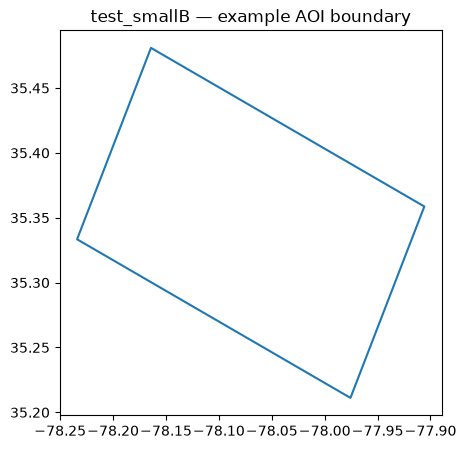

In [2]:
import geopandas as gpd

boundary = gpd.read_file(BOUNDARY)
ax = boundary.plot(
    figsize=(5, 5), facecolor="none", edgecolor="tab:blue", linewidth=1.5
)
ax.set_title("test_smallB — example AOI boundary")
boundary

#### **Reference datasets (fetched on demand)**

The crosswalk and calibration steps rely on several lookup tables:

* IRIS-SWORD slopes
* NWM recurrence and high-water flows
* USGS rating curves
* Optimized Manning's n
* Channel bathymetry

`fimbox.datasets.fetch_data` pulls each one anonymously from the public SDML S3 bucket on first use, then caches it locally, so **no manual download is needed**. Override the cache location with the `$FIMBOX_DATA_DIR` environment variable.


In [3]:
from fimbox.datasets import DATASETS, fetch_data

print(sorted(DATASETS))  # available aliases

# First call downloads + caches; later calls are instant
print(fetch_data("nwm3_high_water_threshold"))

['acceptable_gages', 'bathymetry_ehydro_ohrfc', 'iris_sword_slopes', 'mannings_optz', 'nwm3_high_water_threshold', 'nwm3_recurrence_flows', 'usgs_rating_curves']
/Users/Supath/Library/Caches/fimbox/nwm3_high_water_threshold_cms.parquet


---
### **2. Stage AOI input data**

`fimbox.getAllInputData` stages every input the downstream pipeline needs into `<out_dir>/<aoi_id>/watershed-data/`:

* 3DEP DEM (reprojected, clipped, hole-filled)
* NWM, NHDPlus HR, or NextGen (ngen) hydrofabric flowlines and catchments, plus NWM lakes
* Headwater points
* FEMA NFHL and NLD levees
* OSM roads and bridges
* USGS gages

**Flexible inputs**

* The AOI can be a **boundary polygon file**, an **8-digit HUC code**, a list of **NWM reach IDs**, or a list of **ngen catchment IDs** (for the ID forms the AOI becomes the dissolved footprint of those catchments).
* Reach-ID runs default to no buffer, staging exactly the reaches requested; pass `buffer_m` to widen the AOI and pull in the neighbouring reaches inside it (usually what HAND needs).
* `source` picks the hydrography: `"nwmmedium"` (default, NWM), `"nwmhigh"` (NHDPlus HR), or `"ngen"` (NextGen hydrofabric). Lakes always come from NWM.
* The **ngen** source is read straight from the community hydrofabric parquet mirror, so only the AOI's rows are fetched — no multi-GB CONUS download. Its streams carry `feature_id` from the NWM comid, so the NWM streamflow sources in step 5 still drive FIM against ngen geometry.
* `fimbox.getAllInputDataBatch` runs several AOIs at once: a flat reach list is one AOI, a nested list is one AOI per inner list, and a flat HUC list is one AOI per HUC.
* You can bring your own flowlines, catchments, or DEM from any source; they are normalized to the pipeline schema automatically.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/download_data.svg" alt="download_data workflow" width="1000"/>
</div>

In [4]:
pp = fimbox.getAllInputData(
    boundary=BOUNDARY,
    out_dir=OUT_DIR,
    buffer_m=5000,  # metres to buffer the boundary for data downloads
    headwater_buffer_cells=8,  # DEM cells to shrink the buffer for the headwater clip
    get_flowlines=True,  # False -> bring your own flowlines
    get_catchments=True,  # False -> bring your own catchments
    source="nwmmedium",  # "nwmmedium" -> NWM; "nwmhigh" -> NHDPlus HR; "ngen" -> NextGen hydrofabric (lakes always NWM)
    identifier=IDENTIFIER,  # filename prefix for all staged hydrography
    # huc8="08060202",         # 8-digit HUC ID — alternative to boundary=...
    # nwm_ids=[18228501, 18229233],  # NWM reach IDs — AOI = their catchment footprint
    # dem_resolution=10,       # 3DEP DEM resolution in metres (1/3/10/30/60)
    # epsg=5070,               # output CRS (NAD83 CONUS Albers)
    # --- ngen hydrofabric AOIs (source="ngen") ---
    # cat_ids=["cat-1096367"], # ngen catchment IDs — implies source="ngen"
    # feature_ids=[11239459],  # NWM comids resolved to ngen reaches via network.hf_id
    # subset_type="nexus",     # "nexus" -> up to the outlet nexus; "catchment" -> stop at the seed
    # --- bring-your-own inputs (any source, any column names) ---
    # flowlines="my_flowlines.gpkg",
    # catchments="my_catchments.gpkg",
    # stream_fields={"ID": "nhdplusid", "order_": "streamorde", "levpa_id": "levelpathi"},
    # catchment_fields={"ID": "nhdplusid"},
    # dem="my_dem.tif",        # reprojected/clipped/hole-filled like a downloaded DEM
)
pp.run()  # full pipeline; or pp.run_dem() / pp.run_nhd() / pp.run_nld() / pp.run_osm()

14:06:38 [INFO] Derived HUC2: 03
14:06:38 [INFO] --- DEM domain / landsea masks ---
14:06:39 [WARNING] No records returned by service for this boundary.
14:06:39 [WARNING] DEM domain service returned no intersecting features.
14:06:39 [WARNING] No records returned by service for this boundary.
14:06:39 [INFO] Land/sea service returned no intersecting features.
14:06:39 [INFO] Study boundary --> wbd.gpkg
14:06:39 [INFO] Study boundary (clipped) --> wbd8_clp.gpkg
14:06:39 [INFO] Buffered boundary (5000 m) --> wbd_buffered.gpkg
14:06:39 [INFO] Case: test_smallB  |  AOI: /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB  |  watershed-data: /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/watershed-data
14:06:39 [INFO] === PreprocessAll: test_smallB ===
14:06:39 [INFO] Output: /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/watershed-data
14:06:39 [INFO] SKIP (exists): dem.tif
14:06:39 [INFO] --- NWM Flowlines / Catchments + NWM Lakes ---
14:06:39 [INFO] --- NWM Flowlines ---
14:06

Everything is now staged under `fimbox_output/test_smallB/watershed-data/` and organized into the following groups:

* **Base spatial inputs**
    * `dem.tif`
    * `wbd_buffered.gpkg`
* **Hydrography**
    * `nwmmr_subset_streams.gpkg`
    * `nwmmr_catchments_proj_subset.gpkg`
    * `nwmmr_lakes_proj_subset.gpkg`
    * headwater points
* **Infrastructure and barriers**
    * `3d_nld_subset_levees_burned.gpkg`
    * `osm_roads_subset.gpkg`
    * `osm_bridges_subset.gpkg`
* **Observations**
    * `usgs_gages.gpkg`

All downstream steps read from this staging directory using the shared `IDENTIFIER` prefix (`nwmmr`). The prefix is yours to choose and is independent of `source` — set `IDENTIFIER = "ngen"` for an ngen run and the files become `ngen_subset_streams.gpkg`, `ngen_catchments_proj_subset.gpkg`, and so on.

In [ ]:
# Figure: staged DEM + NWM stream network (axes in WGS84 lon/lat)
import matplotlib.pyplot as plt
import rioxarray
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Reproject the DEM to WGS84 so the axes read out in degrees
dem = rioxarray.open_rasterio(WATERSHED / "dem.tif", masked=True).squeeze()
dem = dem.rio.reproject("EPSG:4326")

fig, ax = plt.subplots(figsize=(5, 5))
dem.plot.imshow(ax=ax, cmap="terrain", add_colorbar=False)
gpd.read_file(WATERSHED / f"{IDENTIFIER}_subset_streams.gpkg").to_crs(4326).plot(
    ax=ax, color="royalblue", linewidth=0.8
)
boundary.to_crs(4326).plot(ax=ax, facecolor="none", edgecolor="crimson", linewidth=1.2)
ax.set_title("Staged inputs — DEM, NWM streams, AOI boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# DEM colorbar outside the plot
sm = plt.cm.ScalarMappable(
    cmap="terrain", norm=plt.Normalize(vmin=float(dem.min()), vmax=float(dem.max()))
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2.5%", pad=0.15)
fig.colorbar(sm, cax=cax, label="Elevation (m)")

plt.show()

---
### **3. Bridge DEM processing *(optional)***

Bridge decks captured in the DEM block flow paths and bias HAND. This step heals them:

1. Streams USGS 3DEP LiDAR around each OSM bridge.
2. Builds a per-bridge elevation raster.
3. Mosaics the `lidar_elev - dem_elev` difference into `bridge_elev_diff.tif`.

Branch processing later uses that raster to heal bridges in the HAND grid.

**Skip this section if your AOI has no bridges.** The rest of the pipeline runs without it.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/process_bridgedem.svg" alt="process_bridgedem workflow" width="1000"/>
</div>

In [ ]:
BRIDGES = WATERSHED / "osm_bridges_subset.gpkg"

# Step 1 — stream USGS LiDAR and write one elevation .tif per bridge.
# Safe to re-run: bridges that already have a raster are skipped
# (check progress anytime with .status() instead of .run()).
tif_dir = fimbox.generateBridgeRaster(
    bridge_gpkg=BRIDGES,
    out_dir=WATERSHED,
    resolution=10.0,  # m, output raster resolution
    buffer_m=10.0,  # m, buffer around each bridge footprint
    n_workers=N_WORKERS,
    # id_col="my_id",  # only needed if the gpkg has no "osmid" column
).run()

# Step 2 — mosaic the per-bridge (lidar - dem) differences into one raster.
diff_path = fimbox.BridgeDEMDiff(
    dem_path=WATERSHED / "dem.tif",
    lidar_tif_dir=tif_dir,
    bridge_gpkg=BRIDGES,
    out_dir=WATERSHED,
    out_name="bridge_elev_diff.tif",
    n_workers=N_WORKERS,
).run()

print(f"Bridge difference raster -> {diff_path}")

---
### **4. Branch processing: HAND + synthetic rating curves**

The core HAND step, following the NOAA OWP inundation-mapping workflows (https://github.com/NOAA-OWP/inundation-mapping).

* `BranchDerivation` derives level paths from the staged stream network and splits the AOI into **branches**.
* `calculate_allbranches` then runs the full HAND workflow:
    * **Branch zero** first: whole-AOI DEM conditioning (AGREE stream burning, levee burning, pit-filling, D8 flow directions).
    * **Every non-zero branch** next, in parallel, through the full 22-step workflow: relative elevation model (HAND), catchments, synthetic rating curves (SRC), the NWM crosswalk, and the per-branch `hydroTable_<branch>.csv` that FIM generation consumes.

**Parameter reference.** Every parameter is spelled out in the cell below so it doubles as the parameter reference. The commented values are the defaults, and each one is an experimentation knob. For example:

* `mannings_n` sets channel roughness.
* `max_split_distance_m` controls stream segmentation density.
* `src_slope_source` picks the slope feeding Manning's equation.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/calculate_branch.svg" alt="calculate_branch workflow" width="1000"/>
</div>

In [ ]:
from fimbox import AOIProcessingConfig, BranchDerivation, calculate_allbranches

# derive level paths, branch polygons, and branch_ids.lst
BranchDerivation(
    out_dir=WATERSHED,
    branch_id_attribute="levpa_id",
    reach_id_attribute="ID",
    branch_buffer_distance_meters=7000.0,
).run()

# optional inputs: passed only when staged by the earlier sections
bridge_diff = WATERSHED / "bridge_elev_diff.tif"  # section 3
levees = WATERSHED / "3d_nld_subset_levees_burned.gpkg"  # section 2
headwaters = WATERSHED / f"{IDENTIFIER}_headwater_points_subset.gpkg"
if not headwaters.exists():
    headwaters = WATERSHED / f"{IDENTIFIER}_headwaters.gpkg"
levelpaths_ext = WATERSHED / f"{IDENTIFIER}_subset_streams_levelPaths_extended.gpkg"
gages = WATERSHED / "usgs_gages.gpkg"  # section 2 (empty AOIs stage nothing)

cfg = AOIProcessingConfig(
    aoi_dir=WATERSHED,
    branch_list_path=WATERSHED / "branch_ids.lst",
    # Branch-zero inputs (whole-AOI DEM conditioning)
    dem_path=WATERSHED / "dem.tif",
    streams_gpkg=WATERSHED / f"{IDENTIFIER}_subset_streams.gpkg",
    boundary_gpkg=WATERSHED / "wbd_buffered.gpkg",
    bridge_elev_diff_path=bridge_diff if bridge_diff.exists() else None,
    levee_gpkg_path=levees if levees.exists() else None,
    headwaters_gpkg=headwaters if headwaters.exists() else None,
    levelpaths_extended_gpkg=levelpaths_ext if levelpaths_ext.exists() else None,
    usgs_gages_gpkg=gages if gages.exists() else None,  # -> gage crosswalk
    gage_aoi_filter_column="aoi_id",  # boundary AOIs tag gages by aoi_id (HUC runs use HUC8)
    # AGREE DEM conditioning
    agree_buffer_m=15.0,
    agree_smooth_drop=10.0,
    agree_sharp_drop=1000.0,
    # HAND geometry
    cost_distance_tolerance=50.0,  # m, lateral cost distance
    lateral_elevation_threshold=10,  # m, lateral thalweg drop cap
    max_split_distance_m=1500.0,  # m, split-reach max length (shorter -> denser catchments)
    slope_min=0.0001,  # rise/run floor
    lakes_buffer_dist_m=100.0,  # m, lake-boundary buffer
    # SRC / crosswalk
    mannings_n=0.06,  # channel roughness
    stage_min_m=0.0,  # SRC stage ladder start
    stage_interval_m=0.3048,  # SRC stage step (1 ft)
    stage_max_m=25.2984,  # SRC stage ladder end (~83 ft)
    min_catchment_area=0.25,  # km^2, short-reach replace threshold
    min_stream_length=0.5,  # km, short-reach replace threshold
    crosswalk_max_distance_m=100.0,  # m, midpoint-to-NWM-flowline cap
    # SRC slope source: "iris_sword" (default) | "dem" | "hfab"
    src_slope_source="iris_sword",
    iris_slope_csv=None,  # None -> packaged IRIS-SWORD table
    hfab_slope_column=None,  # hydrofabric slope column if not Slope/So
    # execution
    n_workers=N_WORKERS,
    keep_failed_branches=True,  # keep failed branch dirs for inspection
    delete_deny_list=True,  # remove per-branch intermediates when done
)

result = calculate_allbranches(
    cfg,
    run_branch_zero=True,
    delete_deny_list=True,  # deny lists default to the ones shipped in fimbox/config/
    branch_ids_csv=WATERSHED / "branch_ids.csv",
)

ok = sum(1 for r in result.branch_results if r.status == "ok")
print(f"branches ok: {ok}/{len(result.branch_results)}")

Each branch now has its own directory under `watershed-data/branches/<branch_id>/`:

* `rem_zeroed_masked_<b>.tif` is the **HAND raster**.
* `gw_catchments_reaches_filtered_addedAttributes_crosswalked_<b>.gpkg` holds the crosswalked catchments.
* `hydroTable_<b>.csv` is the **stage to discharge lookup** used by FIM generation.
* `src_full_crosswalked_<b>.csv` and `src_<b>.json` hold the synthetic rating curves.

Branch `0` covers the whole AOI, and its D8 flow directions are the shared input for every other branch. `branch_ids.csv` summarizes the run status per branch.


In [ ]:
# Figure: HAND raster for one branch (axes in WGS84 lon/lat)
import matplotlib.pyplot as plt
import rioxarray
from mpl_toolkits.axes_grid1 import make_axes_locatable

branch = "0"  # pick any id from branch_ids.csv
hand_path = WATERSHED / "branches" / branch / f"rem_zeroed_masked_{branch}.tif"

CMAP = "turbo"
hand = rioxarray.open_rasterio(hand_path, masked=True).squeeze()
hand = hand.rio.reproject("EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 6))
hand.plot.imshow(
    ax=ax,
    cmap=CMAP,
    vmin=float(hand.min()),
    vmax=float(hand.max()),
    interpolation="nearest",
    add_colorbar=False,
)
ax.set_title(f"Height Above Nearest Drainage (HAND) — branch {branch}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# HAND colorbar outside the plot (same style as the DEM figure)
sm = plt.cm.ScalarMappable(
    cmap=CMAP, norm=plt.Normalize(vmin=float(hand.min()), vmax=float(hand.max()))
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2.5%", pad=0.15)
fig.colorbar(sm, cax=cax, label="HAND (m)")

plt.show()

---
### **5. Rating-curve calibration**

One `run_calibration()` call drives the whole calibration pipeline over the per-branch rating curves and hydroTables, in this order:

1. Reset
2. Pre-aggregation
3. Thalweg-notch adjustment
4. Longitudinal smoothing
5. Bathymetric adjustment (eHydro)
6. Bankfull identification
7. Channel and overbank subdivision (variable Manning's n)
8. Non-monotonic fix
9. USGS rating-curve calibration
10. Spatial and manual calibration
11. Post-aggregation
12. Log scan

**Good to know**

* Steps whose input file is absent **self-skip**.
* Every toggle can be turned off independently.
* The lookup tables come straight from `fetch_data` (section 1), so there is nothing to stage by hand.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/calibrate_ratingcurve.svg" alt="calibrate_ratingcurve workflow" width="1000"/>
</div>

In [4]:
from fimbox import CalibrationConfig, run_calibration
from fimbox.datasets import DATASETS, fetch_data

N_WORKERS = (
    None  # parallel workers for the heavy steps [default: will use all available cores]
)

cal_cfg = CalibrationConfig(
    # reset — revert hydroTables to the uncalibrated baseline first.
    # Set True when re-calibrating an AOI that was already calibrated.
    calibration_rerun=False,
    # aggregate_pre — assemble usgs/ras2fim elev tables before adjustments
    aggregate_pre=True,
    # thalweg — remove thalweg-notch artifact rows, refill the stage ladder
    thalweg_notches_adjustment=True,
    # longitudinal — smooth hydraulic geometry along reach chains
    longitudinal_filter=True,
    # bathymetry — add missing in-channel area below the DEM (eHydro surveys)
    bathymetry_adjust=True,
    bathy_file_ehydro=fetch_data("bathymetry_ehydro_ohrfc"),
    # bankfull — identify the bankfull stage in every branch SRC
    src_bankfull_toggle=True,
    bankfull_flows_file=fetch_data("nwm3_high_water_threshold"),
    include_branch_zero=True,
    # subdiv — channel/overbank subdivision (needs vmann + bankfull on)
    src_subdiv_toggle=True,
    vmann_input_file=fetch_data("mannings_optz"),
    default_channel_n=0.06,  # used when a feature_id is missing from the vmann table
    default_overbank_n=0.12,
    # nonmonotonic — force monotonic in-channel rating curves
    nonmonotonic_src_adjustment=True,
    nonmonotonic_stream_order_min=4,
    # usgs — calibrate SRCs against USGS rating curves at NWM recurrence flows
    src_adjust_usgs=True,
    usgs_rating_curve_csv=fetch_data("usgs_rating_curves"),
    usgs_acceptable_gages=fetch_data("acceptable_gages"),
    nwm_recur_file=fetch_data("nwm3_recurrence_flows"),
    # spatial — calibrate SRCs against benchmark inundation points
    src_adjust_spatial=True,
    calib_points_file=None,  # None -> step self-skips
    # manual — apply a per-feature_id coefficient table
    manual_calb_toggle=True,
    man_calb_file=None,  # None -> step self-skips
    # aggregate_post — publish htable + bridge + road tables to the AOI root
    aggregate_post=True,
    # log scan — collect error/warning lines into per-AOI summary files
    scan_logs=True,
    # execution
    job_branch_limit=N_WORKERS,
    skip_unimplemented=True,  # warn instead of raising on stub steps
)

run_calibration(AOI_DIR, cal_cfg)

13:46:05 [INFO] === Calibration: test_smallB ===
13:46:05 [INFO] --- aggregate usgs + ras2fim elev tables ---
13:46:05 [INFO] --- BranchAggregator: test_smallB ---
13:46:05 [INFO] --- thalweg notches adjustment ---
13:46:05 [INFO] ThalwegNotchesAdjustment: test_smallB (9 branches, None workers)
13:46:12 [INFO] --- longitudinal discharge adjustment ---
13:46:12 [INFO] LongitudinalFlowFilter: test_smallB (9 branches, None workers)
13:48:03 [INFO] --- bathymetry adjustment ---
13:48:03 [INFO] BathymetricAdjustment: test_smallB (ai_toggle=0)
13:48:03 [INFO] --- eHydro bathymetry ---
13:48:03 [INFO] BathymetricAdjustment: 10 branches, None workers
13:48:07 [INFO] --- SRC bankfull identification ---
13:48:07 [INFO] SrcBankfull: 10 branches, None workers
13:48:14 [INFO] --- SRC channel/overbank subdivision ---
13:48:14 [INFO] SrcSubdiv: 10 branches, None workers
13:48:22 [INFO] --- nonmonotonic SRC adjustment ---
13:48:24 [INFO] SrcNonmonotonic: 9 non-zero branches, None workers
13:48:34 [INF

Calibration rewrites the branch tables in place and publishes the aggregates:

* Each branch `hydroTable_<b>.csv` and `src_full_crosswalked_<b>.csv` now carries the calibrated discharges plus the subdivision columns (`subdiv_discharge_cms`, `channel_n`, `overbank_n`, and so on).
* Aggregated tables are published to the AOI root.
* `logs/` gains per-AOI error and warning summaries.


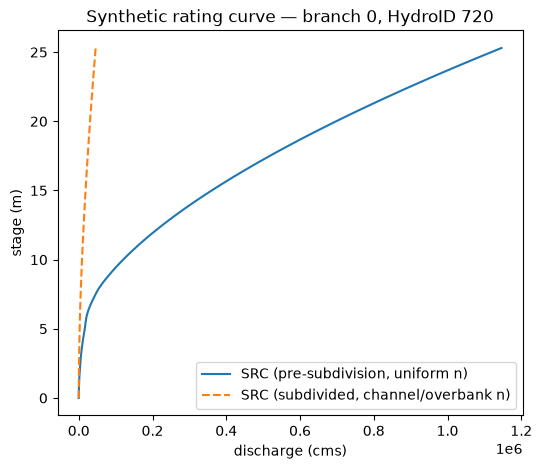

In [ ]:
# Figure: synthetic rating curve before/after subdivision for one reach
import matplotlib.pyplot as plt
import pandas as pd

branch = "0"
src = pd.read_csv(
    WATERSHED / "branches" / branch / f"src_full_crosswalked_{branch}.csv",
    dtype={"HydroID": str},
)
PRE, POST = "Discharge (m3s-1)", "Discharge (m3s-1)_subdiv"

# Auto-pick the reach where subdivision changed the curve the most, so the two
diff = src.assign(_d=(src[PRE] - src[POST]).abs()).groupby("HydroID")["_d"].max()
hydro_id = diff.idxmax() if diff.max() > 1e-6 else src["HydroID"].iloc[0]
curve = src[src["HydroID"] == hydro_id].sort_values("Stage")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(curve[PRE], curve["Stage"], label="SRC (pre-subdivision, uniform n)")
ax.plot(curve[POST], curve["Stage"], "--", label="SRC (subdivided, channel/overbank n)")
ax.set_xlabel("discharge (cms)")
ax.set_ylabel("stage (m)")
ax.set_title(f"Synthetic rating curve — branch {branch}, HydroID {hydro_id}")
ax.legend()
plt.show()

---
### **6. Streamflow retrieval**

`fimbox.streamflow` retrieves the discharge that drives FIM generation and supports its evaluation. Supported sources:

* **NWM v3.0 retrospective**
* **NWM operational forecasts** (short, medium, and long range)
* **GEOGLOWS v2**
* **USGS gage observations**

**Where it lands**

* Retrieved series are archived under `<aoi>/streamflow/`.
* FIM-ready CSVs (`feature_id, discharge_cms`) are exported into `<aoi>/discharge-inputs/`, exactly what the FIM generation step consumes.
* The reach `feature_id`s come from the AOI's `feature_id.csv`, built automatically from the branch hydroTables.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/streamflow.svg" alt="streamflow workflow" width="1000"/>
</div>

In [3]:
from fimbox import getNWMretrospective

# Example case: one retrospective event instant -> one FIM-ready CSV
EVENT = "2016-10-10 12:00:00"
getNWMretrospective(AOI_DIR, date=EVENT)

# other retrieval modes
# getNWMretrospective(AOI_DIR, start="2020-05-19", end="2020-05-22")                    # one CSV per hour
# getNWMretrospective(AOI_DIR, start="2020-05-19", end="2020-05-22", sortby="maximum")  # one aggregated CSV
# getNWMretrospective(AOI_DIR, feature_ids=[123456], date=EVENT)   # explicit reaches
# getNWMforecast(AOI_DIR, "shortrange")                            # latest operational cycle
# getNWMforecast(AOI_DIR, "mediumrange", sort_by="maximum")
# getNWMforecast(AOI_DIR, "shortrange", forecast_date="2024-06-01", hour=12)

13:59:58 [INFO] SKIP (exists): 20161010.parquet
13:59:58 [INFO] FIM-ready discharge (419 reaches) --> NWM_20161010T1200.csv


[PosixPath('/Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/discharge-inputs/NWM_20161010T1200.csv')]

### **Evaluate NWM against USGS observations *(optional)***

`get_usgs_fid_pairs` lists which USGS gage sits on which NWM reach inside the AOI. Pick a pair to:

* Overlay the two hydrographs.
* Compute KGE, NSE, and PBias skill scores.


In [ ]:
from fimbox import get_usgs_fid_pairs

# The pairs come from usgs_subset_gages.gpkg, written by the section-4 gage
# crosswalk when section 2 staged usgs_gages.gpkg. Absent only when the AOI has
# no USGS gages (or those steps were skipped) -> evaluation self-skips.
try:
    pairs = get_usgs_fid_pairs(AOI_DIR)  # which USGS gage sits on which feature_id
    print(pairs)
except FileNotFoundError:
    print("No gage crosswalk found for this AOI — skipping NWM-vs-USGS evaluation.")

# With a pair in hand (USGS_SITE, FEATURE_ID from `pairs` above):
# START, END = "2020-05-01", "2020-06-01"
# USGSData(AOI_DIR).fetch([USGS_SITE], START, END)                   # archive observations
# plot_comparison(AOI_DIR, FEATURE_ID, USGS_SITE, START, END)        # NWM vs USGS overlay
# calculate_statistics(AOI_DIR, FEATURE_ID, USGS_SITE, START, END)   # KGE / NSE / PBias

14:13:51 [INFO] USGS<->feature_id pairs for AOI test_smallB: 4


       location_id  feature_id
0         02088500     8786063
1         02088682     8790603
2         02089000    11239411
3  351849078163901     8790967


---
### **7. FIM generation**

The final step. `generateFIM` turns discharge into flood maps:

1. Reads every discharge CSV in `<aoi>/discharge-inputs/`.
2. Interpolates each reach's stage from the calibrated hydroTables.
3. Inundates every branch HAND raster in parallel.
4. Mosaics the branches into one AOI-wide raster per CSV in `<aoi>/fim-outputs/`.

Each run produces a **flood extent** raster, and optionally a **depth** raster.

<div align="center">
  <img src="https://raw.githubusercontent.com/sdmlua/fimbox/main/workflows/svg/fimgeneration.svg" alt="fimgeneration workflow" width="1000"/>
</div>

In [6]:
from fimbox import generateFIM

# One flood map (extent + depth) per discharge CSV staged in section 6
fim_results = generateFIM(
    AOI_DIR, n_workers=N_WORKERS, depth=True
).from_discharge_inputs()

for r in fim_results:
    print(f"extent -> {r.extent_path}")
    print(f"depth  -> {r.depth_path}")

# selection variants
# generateFIM(AOI_DIR).from_discharge_inputs(csv="discharge-inputs/my_event.csv")  # one CSV
# generateFIM(AOI_DIR).from_discharge_inputs(date="2020-05-20 12:00:00")           # by date stamp
# generateFIM(AOI_DIR).from_discharge_inputs(start="2020-05-19", end="2020-05-22") # by range

14:14:55 [INFO] Selected 1/1 discharge CSV(s): NWM_20161010T1200.csv
14:14:55 [INFO] --- FIM generation: NWM_20161010T1200.csv (depth=True) ---
14:14:55 [INFO] FimGenerator: AOI=test_smallB branches=10 backend=dask mosaic=True intermediate_dir=/Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/fim-outputs/tmp
14:14:55 [INFO] Dask worker sizing: cpu_count=12, system_ram=64.0 GB, ram_per_branch=8.0 GB => n_workers=8
14:14:55 [INFO] Starting Dask LocalCluster: n_workers=8, threads_per_worker=1, memory_limit=auto, memory governor=disabled
14:14:59 [INFO] Dask dashboard: http://127.0.0.1:60283/status
14:14:59 [INFO] FimGenerator (dask): 10 branches -> 8 workers (dashboard http://127.0.0.1:60283/status)
14:15:06 [INFO] BranchMosaic: merged 10 branches, 2702771 wet pixels, max depth 25.30 m
14:15:06 [INFO] Cleaned up intermediates: /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/fim-outputs/tmp
14:15:06 [INFO] Binary inundation written -> NWM_20161010T1200_inundation.tif


extent -> /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/fim-outputs/NWM_20161010T1200_inundation.tif
depth  -> /Users/Supath/Downloads/SDML/FIMBOX/out/test_smallB/fim-outputs/NWM_20161010T1200_depth.tif


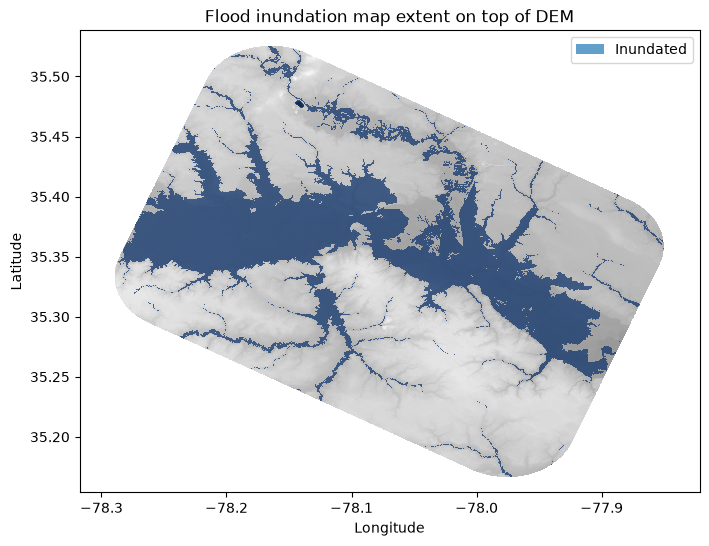

In [9]:
# Figure: the generated flood extent over the DEM (axes in WGS84 lon/lat)
from pathlib import Path

import matplotlib.pyplot as plt
import rioxarray

extent_path = fim_results[0].extent_path

# Reproject both to WGS84 so they share lon/lat axes and align on the plot.
dem = (
    rioxarray.open_rasterio(WATERSHED / "dem.tif", masked=True)
    .squeeze()
    .rio.reproject("EPSG:4326")
)
fim = (
    rioxarray.open_rasterio(extent_path, masked=True)
    .squeeze()
    .rio.reproject("EPSG:4326")
)
fim = fim.where(fim > 0)  # keep flooded cells only; everything else transparent

fig, ax = plt.subplots(figsize=(8, 6))
dem.plot.imshow(ax=ax, cmap="gray", add_colorbar=False)
fim.plot.imshow(ax=ax, cmap="Blues", vmin=0, vmax=1, alpha=0.7, add_colorbar=False)
ax.set_title("Flood inundation map extent on top of DEM")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Legend proxy for the flood overlay
from matplotlib.patches import Patch

ax.legend(
    handles=[Patch(facecolor="tab:blue", alpha=0.7, label="Inundated")],
    loc="upper right",
)

plt.show()

---
### **Wrap-up**

That is the complete `fimbox` workflow for one case:

**Where the outputs live**

| Output | Where |
|---|---|
| Staged AOI inputs | `fimbox_output/test_smallB/watershed-data/` |
| HAND rasters + hydroTables | `watershed-data/branches/<branch_id>/` |
| Streamflow archives + FIM-ready CSVs | `test_smallB/streamflow/`, `test_smallB/discharge-inputs/` |
| Flood extent / depth rasters | `test_smallB/fim-outputs/` |

---

### **Using fimbox as a testbed**

`fimbox` is built for experimentation: change one thing, hold everything else fixed, and see how the FIM responds. You can intervene at three levels, from lightest to deepest:

* **Turn a knob (no code).** Adjust a single parameter in a section and re-run — roughness, segmentation density, the slope source, a calibration toggle, or the forecast product.
* **Change the module logic (edit code).** Any step's underlying computation can be modified in its module and re-run, with everything upstream left untouched. The editable install means a saved edit is live on the next kernel restart.
* **Change the workflow (re-wire steps).** Stages can be swapped, skipped, or replaced — bring your own DEM or stream network, drop a calibration step, or drive the same geometry with a different discharge source.

Keep experiments attributable: change one thing per run, reset calibration between runs (`calibration_rerun=True`), write each run to its own output folder, and compare results quantitatively (e.g. with [FIMeval](https://github.com/sdmlua/fimeval)) rather than by eye.

---

**Further reading**

* Every module ships a README with its full parameter surface and workflow diagram. See the [module documentation table](https://github.com/sdmlua/fimbox#module-documentation).
* The [`tests/`](https://github.com/sdmlua/fimbox/tree/main/tests) folder doubles as a runnable usage reference for every stage.

**Questions and issues**

Reach us at [github.com/sdmlua/fimbox](https://github.com/sdmlua/fimbox), or contact Sagy Cohen (sagy.cohen@ua.edu) or Supath Dhital (sdhital@ua.edu), SDML, The University of Alabama.